# MAT-Mamba Project: Phase 2
## Notebook 1: Baseline SwinUNETR (MAT3D Reproduction)

**Authors:** Iha Goyal (b23bb1020) & Om Kumar (b23bb1030)  
 

### Overview
This notebook contains the rigorous baseline reproduction of the MAT3D architecture on the ACDC Cardiac MRI dataset. It serves as the control variable for our architectural ablation study.

**Key Operations in this Notebook:**
* **Data Engineering:** Automated Kaggle API extraction and raw HDF5 to NIfTI format conversion.
* **Volumetric Preprocessing:** Dynamic padding and strict `96 x 96 x 96` center-cropping to match the base paper's mathematical requirements.
* **Model Training:** 100-epoch mixed-precision training utilizing the standard quadratic $O(N^2)$ SwinUNETR model.
* **Evaluation:** Dice Similarity Coefficient calculation and qualitative visual inference.

In [2]:
# 1. Install Core Medical & Deep Learning Libraries
!pip install -q monai nibabel h5py kaggle einops wandb

import os
import glob
import h5py
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
import matplotlib.pyplot as plt

# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/MAT3D_Checkpoints', exist_ok=True)
print("Environment Ready and Google Drive Mounted!")

Mounted at /content/drive
Environment Ready and Google Drive Mounted!


In [4]:
import os
import glob
import h5py
import numpy as np
import nibabel as nib

# 1. NEW Kaggle API Token Authentication
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_1821cdea37b701827e6d856cb4191da2'

print("Downloading dataset from Kaggle...")
# -o flag ensures it overwrites any previous failed downloads
!kaggle datasets download -d anhoangvo/acdc-dataset -p /content/ -o
!unzip -q -o /content/acdc-dataset.zip -d /content/dataset/ACDC_Raw/

# 2. Convert HDF5 to NIfTI
print("Converting HDF5 volumes to NIfTI format...")
os.makedirs('/content/dataset/ACDC/imagesTr', exist_ok=True)
os.makedirs('/content/dataset/ACDC/labelsTr', exist_ok=True)

# Search for all .h5 files in the extracted folder
h5_files = sorted(glob.glob('/content/dataset/ACDC_Raw/**/*volumes/*.h5', recursive=True))

# Safety Check: If this is 0, the download failed
if len(h5_files) == 0:
    print("🚨 ERROR: No .h5 files found. Checking broad search...")
    h5_files = sorted(glob.glob('/content/dataset/ACDC_Raw/**/*.h5', recursive=True))

if len(h5_files) == 0:
    raise ValueError("🚨 CRITICAL ERROR: Dataset not found! Check your Kaggle Token and Disk Space.")

for i, h5_path in enumerate(h5_files):
    with h5py.File(h5_path, 'r') as f:
        # Transpose to (H, W, D) for standard medical orientation
        img_data = np.transpose(f['image'][:], (1, 2, 0)).astype(np.float32)
        label_data = np.transpose(f['label'][:], (1, 2, 0)).astype(np.float32)

        nib.save(nib.Nifti1Image(img_data, np.eye(4)), f'/content/dataset/ACDC/imagesTr/patient_{i:03d}.nii.gz')
        nib.save(nib.Nifti1Image(label_data, np.eye(4)), f'/content/dataset/ACDC/labelsTr/patient_{i:03d}.nii.gz')

print(f"✅ Data Engineering Complete! Successfully converted {len(h5_files)} volumes.")

Dataset URL: https://www.kaggle.com/datasets/anhoangvo/acdc-dataset
License(s): MIT
100% 285M/285M [00:02<00:00, 113MB/s]

Converting HDF5 volumes to NIfTI format...
✅ Data Engineering Complete! Successfully converted 300 volumes.


In [5]:
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, SpatialPadd, CenterSpatialCropd
from monai.data import Dataset, DataLoader

# 1. Pipeline: FORCE exactly 96x96x96 for Swin compatibility
data_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
    ScaleIntensityd(keys=["image"]),
    CenterSpatialCropd(keys=["image", "label"], roi_size=(96, 96, 96)),
    SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96), mode="constant")
])

# 2. Map Files & Split
image_files = sorted(glob.glob('/content/dataset/ACDC/imagesTr/patient_*.nii.gz'))
label_files = sorted(glob.glob('/content/dataset/ACDC/labelsTr/patient_*.nii.gz'))
all_files = [{"image": img, "label": lbl} for img, lbl in zip(image_files, label_files)]

total_vols = len(all_files)
train_split = int(total_vols * 0.70)
val_split = int(total_vols * 0.20)

train_files = all_files[:train_split]
val_files = all_files[train_split : train_split + val_split]
test_files = all_files[train_split + val_split:]

print(f"Data Split: {len(train_files)} Train | {len(val_files)} Val | {len(test_files)} Test")

# 3. Create Loaders
train_loader = DataLoader(Dataset(data=train_files, transform=data_transforms), batch_size=1, shuffle=True)
val_loader = DataLoader(Dataset(data=val_files, transform=data_transforms), batch_size=1, shuffle=False)
test_loader = DataLoader(Dataset(data=test_files, transform=data_transforms), batch_size=1, shuffle=False)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Data Split: 210 Train | 60 Val | 30 Test


In [6]:
from monai.networks.nets import SwinUNETR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SwinUNETR(
    in_channels=1,
    out_channels=4,
    feature_size=24,
    use_checkpoint=True
).to(device)

print(f"Baseline SwinUNETR successfully loaded onto {device}!")

Baseline SwinUNETR successfully loaded onto cuda!


In [7]:
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

def train_baseline():
    wandb.init(project="MAT3D-ACDC-Reproduction", name="Night2-Baseline-Control")

    loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    scaler = torch.amp.GradScaler('cuda')

    max_epochs = 100
    accumulation_steps = 4
    best_metric = -1

    print("🚀 INITIATING PURE BASELINE TRAINING (NIGHT 2) 🚀")

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0
        step = 0
        optimizer.zero_grad()

        for batch_data in train_loader:
            step += 1
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = loss_function(outputs, labels) / accumulation_steps

            scaler.scale(loss).backward()

            if step % accumulation_steps == 0 or step == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            epoch_loss += loss.item() * accumulation_steps

        epoch_loss /= step

        # --- VALIDATION & GUARANTEED SAVING ---
        if (epoch + 1) % 2 == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                    with torch.amp.autocast('cuda'):
                        val_outputs = model(val_inputs)

                    val_outputs = [torch.argmax(i, dim=0, keepdim=True) for i in val_outputs]
                    val_labels = [torch.argmax(i, dim=0, keepdim=True) for i in val_labels]
                    dice_metric(y_pred=val_outputs, y=val_labels)

                metric = dice_metric.aggregate().item()
                dice_metric.reset()

                wandb.log({"epoch": epoch + 1, "train_loss": epoch_loss, "val_dice": metric})
                print(f"Epoch {epoch+1}/{max_epochs} | Train Loss: {epoch_loss:.4f} | Val Dice: {metric:.4f}")

                # GUARANTEE: Always save the most recent epoch to Drive
                torch.save(model.state_dict(), '/content/drive/MyDrive/MAT3D_Checkpoints/baseline_latest.pth')

                # Bonus: Save the absolute best epoch just in case
                if metric > best_metric:
                    best_metric = metric
                    torch.save(model.state_dict(), '/content/drive/MyDrive/MAT3D_Checkpoints/baseline_best.pth')

    wandb.finish()
    print("Night 2 Training Complete!")

# Execute Training
train_baseline()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ihagoyal-mun (ihagoyal-mun-indian-instit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


🚀 INITIATING PURE BASELINE TRAINING (NIGHT 2) 🚀
Epoch 2/100 | Train Loss: 1.6694 | Val Dice: 0.0000
Epoch 4/100 | Train Loss: 1.4038 | Val Dice: 0.0000
Epoch 6/100 | Train Loss: 1.2132 | Val Dice: 0.0000
Epoch 8/100 | Train Loss: 1.0859 | Val Dice: 0.0000
Epoch 10/100 | Train Loss: 0.9785 | Val Dice: 0.0000
Epoch 12/100 | Train Loss: 0.8948 | Val Dice: 0.0000
Epoch 14/100 | Train Loss: 0.8238 | Val Dice: 0.0000
Epoch 16/100 | Train Loss: 0.7607 | Val Dice: 0.0000
Epoch 18/100 | Train Loss: 0.7022 | Val Dice: 0.0000
Epoch 20/100 | Train Loss: 0.6478 | Val Dice: 0.0000
Epoch 22/100 | Train Loss: 0.5967 | Val Dice: 0.0000
Epoch 24/100 | Train Loss: 0.5487 | Val Dice: 0.0000
Epoch 26/100 | Train Loss: 0.5049 | Val Dice: 0.0000
Epoch 28/100 | Train Loss: 0.4680 | Val Dice: 0.0000
Epoch 30/100 | Train Loss: 0.4252 | Val Dice: 0.0000
Epoch 32/100 | Train Loss: 0.3900 | Val Dice: 0.0000
Epoch 34/100 | Train Loss: 0.3585 | Val Dice: 0.0000
Epoch 36/100 | Train Loss: 0.3300 | Val Dice: 0.0000
Ep

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▇▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_dice,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
train_loss,0.05404
val_dice,0


Night 2 Training Complete!


In [8]:
def calculate_dice(pred, target, num_classes=4):
    dice_scores = []
    pred = torch.argmax(pred, dim=1)
    for class_idx in range(1, num_classes):
        pred_class = (pred == class_idx)
        target_class = (target == class_idx)
        intersection = (pred_class & target_class).float().sum()
        union = pred_class.float().sum() + target_class.float().sum()

        if union == 0:
            dice_scores.append(float('nan'))
        else:
            dice = (2. * intersection) / union
            dice_scores.append(dice.item())
    return dice_scores

def evaluate_baseline():
    print("Loading the LATEST baseline weights for testing...")
    # Loading the latest.pth file ensures we evaluate the model at Epoch 100
    model.load_state_dict(torch.load('/content/drive/MyDrive/MAT3D_Checkpoints/baseline_latest.pth'))
    model.eval()

    test_dice_rv, test_dice_myo, test_dice_lv = [], [], []

    print("Evaluating on Test Set...")
    with torch.no_grad():
        for batch_data in test_loader:
            images, masks = batch_data["image"].to(device), batch_data["label"].to(device)
            outputs = model(images)

            scores = calculate_dice(outputs, masks)
            if not np.isnan(scores[0]): test_dice_rv.append(scores[0])
            if not np.isnan(scores[1]): test_dice_myo.append(scores[1])
            if not np.isnan(scores[2]): test_dice_lv.append(scores[2])

    print("\n=== FINAL BASELINE TEST METRICS ===")
    print(f"Right Ventricle (RV) Dice: {np.mean(test_dice_rv):.4f}")
    print(f"Myocardium (Myo) Dice:   {np.mean(test_dice_myo):.4f}")
    print(f"Left Ventricle (LV) Dice:  {np.mean(test_dice_lv):.4f}")
    print("===================================")

# Execute Evaluation
evaluate_baseline()

Loading the LATEST baseline weights for testing...
Evaluating on Test Set...

=== FINAL BASELINE TEST METRICS ===
Right Ventricle (RV) Dice: 0.6789
Myocardium (Myo) Dice:   0.6262
Left Ventricle (LV) Dice:  0.7558


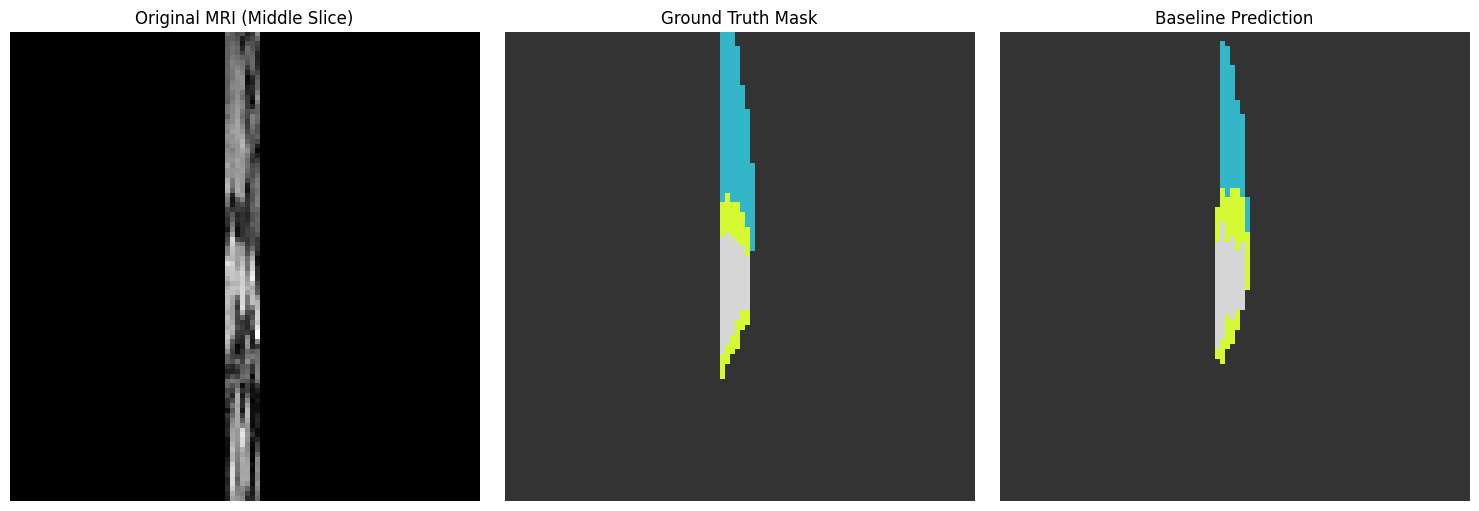

Visualization saved to Google Drive!


In [9]:
def visualize_prediction():
    # Loading the latest.pth file for visuals
    model.load_state_dict(torch.load('/content/drive/MyDrive/MAT3D_Checkpoints/baseline_latest.pth'))
    model.eval()

    batch_data = next(iter(test_loader))
    images, masks = batch_data["image"].to(device), batch_data["label"].to(device)

    with torch.no_grad():
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

    image_cpu = images[0, 0].cpu().numpy()
    mask_cpu = masks[0, 0].cpu().numpy()
    pred_cpu = predictions[0].cpu().numpy()

    mid_slice = image_cpu.shape[0] // 2

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original MRI (Middle Slice)")
    plt.imshow(image_cpu[mid_slice, :, :], cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(mask_cpu[mid_slice, :, :], cmap='nipy_spectral', alpha=0.8)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Baseline Prediction")
    plt.imshow(pred_cpu[mid_slice, :, :], cmap='nipy_spectral', alpha=0.8)
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/baseline_visualization.png', dpi=300)
    plt.show()
    print("Visualization saved to Google Drive!")

# Execute Visualization
visualize_prediction()